# How Can a Wellness Technology Company Play It Smart?

**Bellabeat — Capstone for Google Data Analytics Professional Certificate**

## The Challenge

Bellabeat, a high-tech wellness company focused on women's health, wants to expand its market position in the global smart device industry. By analyzing how consumers use non-Bellabeat smart devices, we can uncover patterns and opportunities to refine Bellabeat's marketing strategy and product offerings.

**Key Questions:**
- What behavioral patterns emerge from smart device usage data?
- How can these insights inform targeted marketing campaigns?
- Which product features should Bellabeat emphasize to maximize user engagement?

## The Data

**Source:** [FitBit Fitness Tracker Data](https://www.kaggle.com/datasets/arashnic/fitbit) (CC0: Public Domain)
- **33 users** (activity dataset) and **24 users** (sleep dataset) who consented to share personal tracker data
- **Daily activity metrics:** steps, distance, intensity levels, calories
- **Sleep tracking:** duration, efficiency, time in bed
- **Credibility:** Kaggle usability score of 9.41

## Setup & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_theme(style="whitegrid")

# Load datasets
daily_activity = pd.read_csv("../data/raw/fitabase_4.12.16-5.12.16/dailyActivity_merged.csv")
sleep_day = pd.read_csv("../data/raw/fitabase_4.12.16-5.12.16/sleepDay_merged.csv")

# Quick data overview
print(f"Daily Activity: {len(daily_activity)} observations from {daily_activity['Id'].nunique()} users")
print(f"Sleep Data: {len(sleep_day)} observations from {sleep_day['Id'].nunique()} users")

Daily Activity: 940 observations from 33 users
Sleep Data: 413 observations from 24 users


## Initial Discovery: The Sedentary Lifestyle Problem

A first look at the data reveals a striking pattern that presents both a challenge and an opportunity for Bellabeat.

Average daily steps: 7638
Average sedentary time: 16.5 hours per day



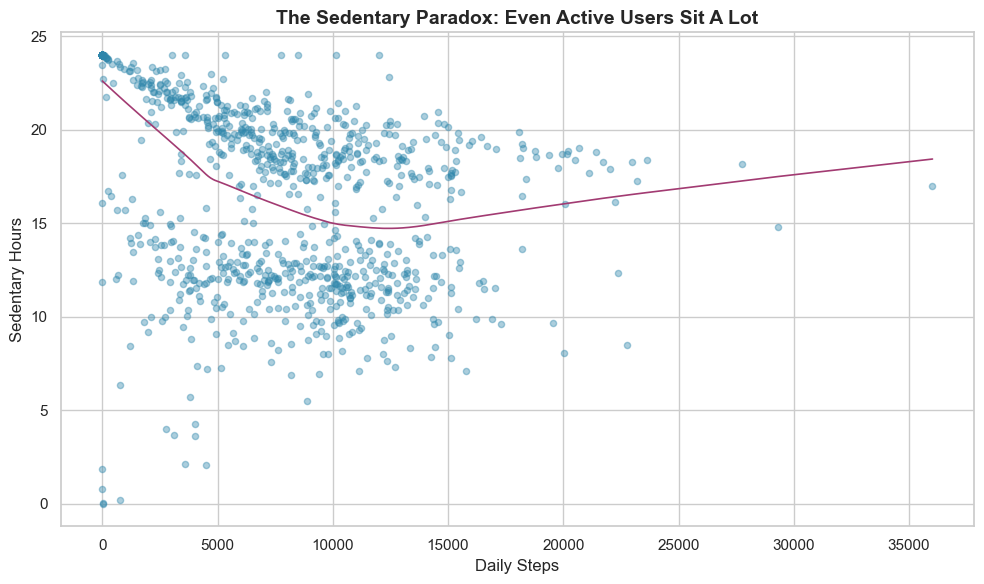

In [2]:
# Calculate key metrics
avg_steps = daily_activity['TotalSteps'].mean()
avg_sedentary_hours = daily_activity['SedentaryMinutes'].mean() / 60

print(f"Average daily steps: {round(avg_steps)}")
print(f"Average sedentary time: {round(avg_sedentary_hours, 1)} hours per day\n")

# Visualize the relationship
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(daily_activity['TotalSteps'], daily_activity['SedentaryMinutes'] / 60,
           alpha=0.4, color='#2E86AB', s=20)
sns.regplot(x='TotalSteps', y=daily_activity['SedentaryMinutes'] / 60,
            data=daily_activity, lowess=True, scatter=False,
            line_kws={'color': '#A23B72', 'linewidth': 1.2}, ax=ax)
ax.set_title("The Sedentary Paradox: Even Active Users Sit A Lot",
             fontweight='bold', fontsize=14)
ax.set_xlabel("Daily Steps")
ax.set_ylabel("Sedentary Hours")
plt.tight_layout()
plt.show()

**Key Insight:** Users average **16.5 hours of sedentary time daily**, even those hitting 10,000+ steps. This suggests that step count alone doesn't tell the full story—people can be both "active" AND sedentary.

**Marketing Opportunity:** Position Bellabeat's movement reminders and activity tracking as essential tools for breaking up long periods of sitting, not just counting steps.

## Activity Patterns: Three Distinct User Segments

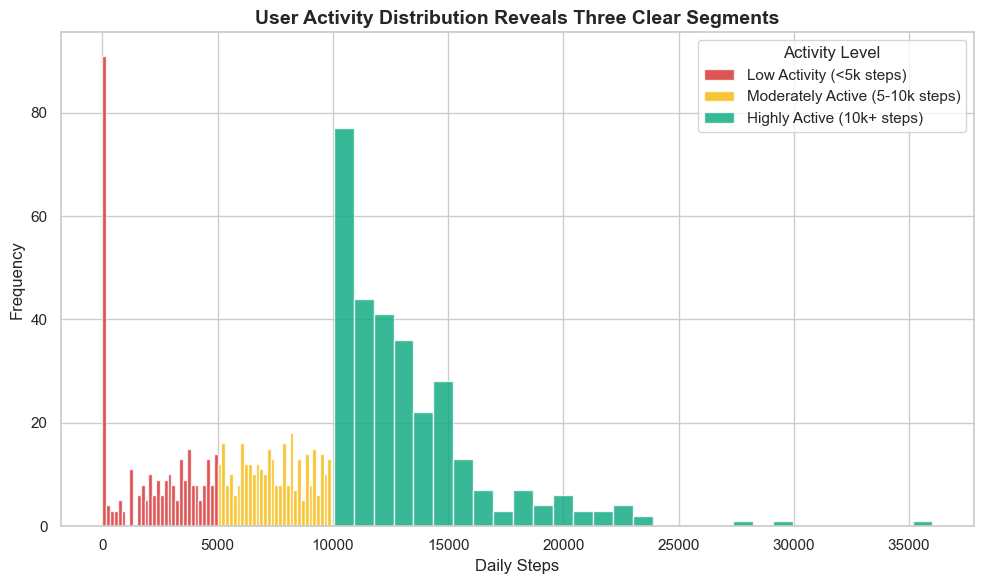

,count,avg_steps,avg_calories
activity_segment,,,
Moderately Active (5-10k steps),334,7466.0,2355.0
Highly Active (10k+ steps),303,13337.0,2744.0
Low Activity (<5k steps),303,2128.0,1807.0


In [3]:
# Segment users by activity level
def assign_segment(steps):
    if steps >= 10000:
        return "Highly Active (10k+ steps)"
    elif steps >= 5000:
        return "Moderately Active (5-10k steps)"
    else:
        return "Low Activity (<5k steps)"

daily_activity['activity_segment'] = daily_activity['TotalSteps'].apply(assign_segment)

# Count users in each segment
segment_distribution = (daily_activity.groupby('activity_segment')
    .agg(count=('TotalSteps', 'size'),
         avg_steps=('TotalSteps', 'mean'),
         avg_calories=('Calories', 'mean'))
    .assign(avg_steps=lambda x: x['avg_steps'].round(),
            avg_calories=lambda x: x['avg_calories'].round())
    .sort_values('count', ascending=False))

# Visualize distribution
color_map = {
    "Highly Active (10k+ steps)": "#06A77D",
    "Moderately Active (5-10k steps)": "#F5B700",
    "Low Activity (<5k steps)": "#D62828"
}
segment_order = ["Low Activity (<5k steps)", "Moderately Active (5-10k steps)",
                 "Highly Active (10k+ steps)"]
colors = [color_map[s] for s in segment_order]

fig, ax = plt.subplots(figsize=(10, 6))
for seg, color in zip(segment_order, colors):
    subset = daily_activity[daily_activity['activity_segment'] == seg]
    ax.hist(subset['TotalSteps'], bins=30, alpha=0.8, color=color, label=seg)
ax.set_title("User Activity Distribution Reveals Three Clear Segments",
             fontweight='bold', fontsize=14)
ax.set_xlabel("Daily Steps")
ax.set_ylabel("Frequency")
ax.legend(title="Activity Level", loc='upper right')
plt.tight_layout()
plt.show()

segment_distribution

**Marketing Strategy:** Create **segment-specific messaging**:
- **Highly Active:** "Track your peak performance" - emphasize advanced metrics
- **Moderately Active:** "Small steps, big progress" - encourage consistency
- **Low Activity:** "Start where you are" - focus on achievable goals and gentle nudges

## Sleep Analysis: Quality Over Quantity

Average sleep duration: 7.0 hours
Average sleep efficiency: 91.7%



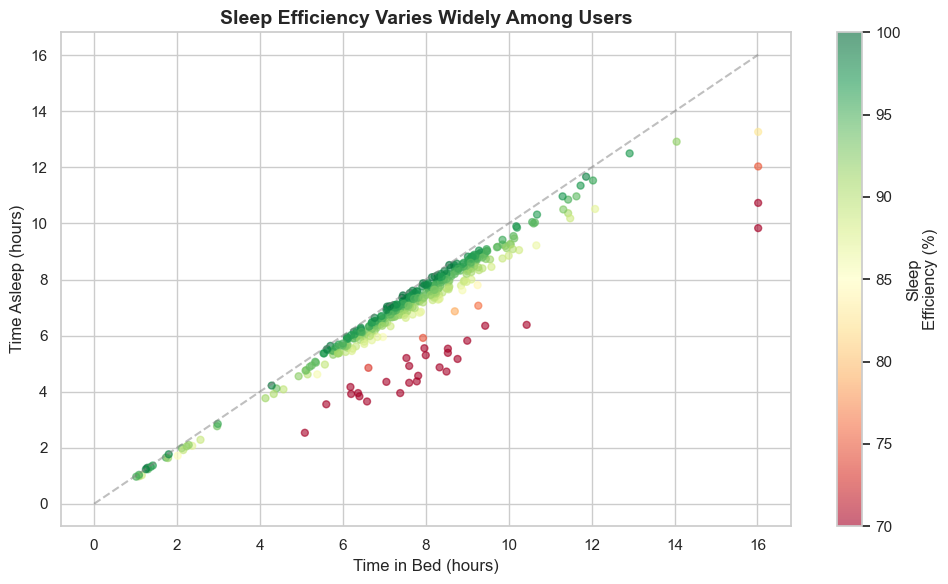

In [4]:
# Calculate sleep efficiency
sleep_day['sleep_efficiency'] = (sleep_day['TotalMinutesAsleep'] / sleep_day['TotalTimeInBed']) * 100
sleep_day['sleep_hours'] = sleep_day['TotalMinutesAsleep'] / 60

# Summary statistics
print(f"Average sleep duration: {round(sleep_day['sleep_hours'].mean(), 1)} hours")
print(f"Average sleep efficiency: {round(sleep_day['sleep_efficiency'].mean(), 1)}%\n")

# Visualize sleep efficiency
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(sleep_day['TotalTimeInBed'] / 60,
                     sleep_day['TotalMinutesAsleep'] / 60,
                     c=sleep_day['sleep_efficiency'],
                     cmap='RdYlGn', vmin=70, vmax=100,
                     alpha=0.6, s=25)
max_val = max((sleep_day['TotalTimeInBed'] / 60).max(),
              (sleep_day['TotalMinutesAsleep'] / 60).max())
ax.plot([0, max_val], [0, max_val], linestyle='--', color='gray', alpha=0.5)
cbar = plt.colorbar(scatter, ax=ax, label='Sleep\nEfficiency (%)')
ax.set_title("Sleep Efficiency Varies Widely Among Users",
             fontweight='bold', fontsize=14)
ax.set_xlabel("Time in Bed (hours)")
ax.set_ylabel("Time Asleep (hours)")
plt.tight_layout()
plt.show()

**Key Finding:** Many users spend significantly more time in bed than actually sleeping, indicating **sleep efficiency problems**. Points far below the diagonal line represent users losing 30+ minutes to restlessness, difficulty falling asleep, or mid-sleep wakings.

**Product Opportunity:** Develop **sleep environment optimization features** - track factors like room temperature, light, noise, and suggest personalized improvements to increase sleep efficiency.

## Statistical Summary: What the Numbers Tell Us

In [5]:
# Activity summary
print("=== ACTIVITY METRICS ===")
print(daily_activity[['TotalSteps', 'TotalDistance', 'Calories', 'SedentaryMinutes',
                       'VeryActiveMinutes', 'FairlyActiveMinutes',
                       'LightlyActiveMinutes']].describe().round(2))

print("\n=== SLEEP METRICS ===")
print(sleep_day[['TotalMinutesAsleep', 'TotalTimeInBed',
                  'sleep_efficiency']].describe().round(2))

=== ACTIVITY METRICS ===
       TotalSteps  TotalDistance  Calories  SedentaryMinutes  \
count      940.00         940.00    940.00            940.00   
mean      7637.91           5.49   2303.61            991.21   
std       5087.15           3.92    718.17            301.27   
min          0.00           0.00      0.00              0.00   
25%       3789.75           2.62   1828.50            729.75   
50%       7405.50           5.24   2134.00           1057.50   
75%      10727.00           7.71   2793.25           1229.50   
max      36019.00          28.03   4900.00           1440.00   

       VeryActiveMinutes  FairlyActiveMinutes  LightlyActiveMinutes  
count             940.00               940.00                940.00  
mean               21.16                13.56                192.81  
std                32.84                19.99                109.17  
min                 0.00                 0.00                  0.00  
25%                 0.00                 0.00   

## Key Insights & Strategic Recommendations

### 🎯 Core Findings

1. **The Activity Paradox:** Users can be both active (meeting step goals) AND highly sedentary (16+ hours sitting). Traditional metrics miss this nuance.

2. **Three Distinct Markets:** User behavior clusters into clear segments requiring different messaging and features.

3. **Sleep Quality Gap:** Average sleep duration (~7 hours) is acceptable, but poor efficiency means users could feel more rested with the same time investment.

### 💡 Actionable Marketing Strategies

**1. "Beyond Steps" Campaign**
- Target: All user segments
- Message: "Your fitness tracker counts steps. Bellabeat transforms your entire day."
- Focus: Highlight holistic health tracking—movement patterns throughout the day, not just total steps

**2. Segment-Specific Onboarding**
- Customize app experience based on initial activity assessment
- Highly Active → Advanced analytics, performance trends, competitive challenges
- Moderately Active → Progress tracking, streak rewards, achievable milestones
- Low Activity → Gentle reminders, micro-goals, educational content

**3. "Sleep Smarter" Feature Set**
- Emphasize sleep efficiency metrics over just duration
- Market Bellabeat's ability to identify environmental factors affecting sleep quality
- Create shareable "Sleep Score" to encourage engagement

### 🚀 Product Development Priorities

1. **Sedentary Break Alerts:** Smart notifications that learn user patterns and suggest optimal movement breaks
2. **Sleep Environment Monitoring:** Partner features or integrations for temperature, light, and sound tracking
3. **Personalized Insights Engine:** Use ML to provide segment-appropriate recommendations

### 📊 Success Metrics

- Increase in average daily active minutes (not just steps)
- Improved sleep efficiency scores among users
- Higher engagement rates with segment-tailored content
- Growth in Bellabeat membership conversions from free users

## Limitations & Next Steps

**Data Limitations:**
- Small sample size (33 users for activity, 24 for sleep) may not fully represent Bellabeat's target demographic
- One-month observation window limits understanding of long-term behavior patterns
- No demographic data (age, gender, lifestyle) prevents deeper segmentation
- Missing context on device wearing compliance and data accuracy

**Recommended Follow-Up Analysis:**
1. **Survey existing Bellabeat users** to validate findings and gather demographic context
2. **Conduct A/B testing** on segment-specific messaging to measure engagement impact
3. **Analyze seasonal variations** in activity and sleep patterns for better feature timing
4. **Investigate correlations** between sleep efficiency and next-day activity levels

---

*Analysis completed using Python (pandas, matplotlib, seaborn) | Data: FitBit Fitness Tracker Dataset (Kaggle)*